In [4]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


In [5]:
import pandas as pd

df = pd.read_csv("../data/17_열처리.csv")

import matplotlib.pyplot as plt

실습5. 다중 센서 비교 그래프와 저장
반복문으로 세 설비를 비교하고 이미지로 저장

목표
반복문으로 세 설비를 겹쳐 비교하고 이미지로 저장

단계
· 설비 이름과 색 목록을 반복하며 각 설비 온도 선 그리기
· 제목·축 이름·범례로 그래프를 완성
· savefig로 그래프를 이미지 파일로 저장(show보다 먼저)

예상 결과
세 설비 온도 비교 그래프가 파일로 저장

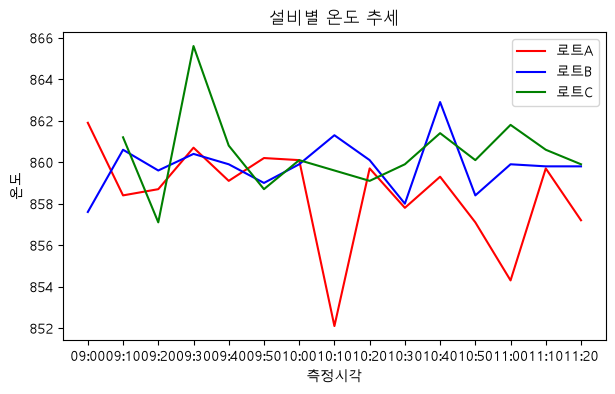

In [6]:
plt.figure(figsize=(7, 4)) # 전체 그래프의 크기
plt.title('설비별 온도 추세')

names = [ ('로트A', 'red'),
          ('로트B', 'blue'),
          ('로트C', 'green')]

for (name, color) in names:
  df_name = df[df['배치'] == name]
  plt.plot(df_name['측정시각'], df_name['온도'], label = name, color = color)

plt.legend(loc = "upper right")
plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')
plt.show()